# 6.4 - CertCF atlas subsampling diagnostics

This notebook helps choose `k_per_class` for CertCF before a large benchmark run.

The goal is to understand whether the current prototype budget is large enough for each dataset by looking at four complementary signals:

1. prototype compression quality
2. certified atlas coverage on same-class training points
3. empirical atlas overlap on same-class training points
4. pilot query stability for CertCF itself

This notebook is intentionally manual and self-contained. It does not use `notebooks/utils/` so the analysis remains easy to inspect and modify cell by cell.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

for candidate in [ROOT, ROOT / "src"]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import display
from scipy.spatial.distance import cdist
from torch.utils.data import TensorDataset
from tqdm.auto import tqdm

from certcf.atlas import CertCFAtlas
from certcf.eps_strategies import NearestOppositeClassClearanceStrategy
from counterfactuals.benchmarks.registry import create_default_registries
from counterfactuals.utils.clustering import select_prototype_indices
from scripts.benchmark import _build_query_tasks, _build_torch_model_from_checkpoint

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

warnings.filterwarnings("ignore", message=".*Cluster .* is empty.*")


In [2]:
CONFIG_PATH = ROOT / "configs/benchmarks/benchmark_meeting_all_200q.yaml"

DATASETS = [
    "adult",
    # "compas",
    # "german_credit",
    # "heloc",
    # "give_me_some_credit",
    # "lending_club",
]
K_GRID = [50, 100, 200, 300, 500, 1000]
LIRPA_METHOD = "backward"
CERTCF_PARAM_OVERRIDES = {
    "eps_alpha": 0.45,
}
LOW_MARGIN_QUANTILE = 0.10
MAX_COVERAGE_POINTS_PER_CLASS = 4000
COVERAGE_BATCH_SIZE = 128
PILOT_N_QUERIES = 25
SEED = 42

print(CONFIG_PATH)
print(DATASETS)
print(K_GRID)
print(LIRPA_METHOD)
print(CERTCF_PARAM_OVERRIDES)


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/configs/benchmarks/benchmark_meeting_all_200q.yaml
['adult']
[50, 100, 200, 300, 500, 1000]
backward
{'eps_alpha': 0.45}


In [3]:
with CONFIG_PATH.open() as f:
    BENCHMARK_CFG = yaml.safe_load(f)

DATASET_CFGS = {cfg["name"]: cfg for cfg in BENCHMARK_CFG["datasets"]}
SHARED_METHOD_CFGS = {cfg["name"]: cfg for cfg in BENCHMARK_CFG["methods"]}
REGISTRIES = create_default_registries()

missing = sorted(set(DATASETS).difference(DATASET_CFGS))
if missing:
    raise ValueError(f"Unknown datasets in DATASETS: {missing}")


def _norm_to_cdist_metric(norm_value):
    if norm_value == 1:
        return "cityblock"
    if norm_value == 2:
        return "euclidean"
    if norm_value == np.inf:
        return "chebyshev"
    raise ValueError(f"Unsupported norm for cdist conversion: {norm_value!r}")


def _merge_certcf_params(dataset_name):
    params = dict(SHARED_METHOD_CFGS["certcf"].get("params", {}))
    ds_overrides = DATASET_CFGS[dataset_name].get("method_overrides", {}).get("certcf", {})
    params.update(ds_overrides)
    params.update(CERTCF_PARAM_OVERRIDES)
    return params


def _resolve_lirpa_method(method_name):
    return str(method_name).strip().lower().replace("_", "-")


def _resolve_repo_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    candidates = [ROOT / path, Path.cwd() / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return (ROOT / path).resolve()


def _batched_logits(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            logits = module(x_batch).detach().cpu().numpy()
            outputs.append(logits)
    return np.concatenate(outputs, axis=0)


def _margin_scores(logits, y_true):
    logits = np.asarray(logits, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    true_scores = logits[np.arange(len(y_true)), y_true]
    masked = logits.copy()
    masked[np.arange(len(y_true)), y_true] = -np.inf
    other_scores = masked.max(axis=1)
    return true_scores - other_scores


def _load_dataset_bundle(dataset_name):
    ds_cfg = DATASET_CFGS[dataset_name]
    dataset_params = dict(ds_cfg.get("dataset_params", {"data_dir": "data/"}))
    dataset_params["data_dir"] = str(_resolve_repo_path(dataset_params.get("data_dir", "data/")))
    dataset = REGISTRIES["dataset"].create(dataset_name, **dataset_params)
    dataset.load()

    x_train, y_train = dataset.get_train()
    x_test, y_test = dataset.get_test()
    model_cfg = ds_cfg["model"]
    if model_cfg["name"] != "tabular_classifier_ckpt":
        raise ValueError(f"This notebook only supports tabular checkpoint models, got {model_cfg['name']!r}.")

    model_params = dict(model_cfg.get("params", {}))
    model_params["checkpoint"] = str(_resolve_repo_path(model_params["checkpoint"]))
    model = _build_torch_model_from_checkpoint(
        checkpoint=model_params["checkpoint"],
        device=model_params.get("device", "cpu"),
        dataset_module=model_params.get("dataset_module", dataset_name),
        hidden_dims=list(model_params.get("hidden_dims", [32, 8])),
        dropout=float(model_params.get("dropout", 0.2)),
    )
    certcf_params = _merge_certcf_params(dataset_name)
    cert_norm = np.inf if str(certcf_params.get("norm", 2)).lower() in {"inf", "infinity"} else int(certcf_params.get("norm", 2))
    distance_norm_raw = certcf_params.get("distance_norm", cert_norm)
    distance_norm = np.inf if str(distance_norm_raw).lower() in {"inf", "infinity"} else int(distance_norm_raw)
    query_method = str(certcf_params.get("query_method", "sorted")).lower()
    default_lirpa_method = _resolve_lirpa_method(certcf_params.get("lirpa_method", "backward"))
    spec = getattr(dataset, "spec", None)
    ohe_slices = list(spec.categorical_slices) if spec is not None and len(spec.categorical_slices) else None

    logits = _batched_logits(model, x_train)
    margins = _margin_scores(logits, y_train)

    return {
        "dataset_name": dataset_name,
        "dataset": dataset,
        "spec": spec,
        "x_train": np.asarray(x_train, dtype=np.float32),
        "y_train": np.asarray(y_train, dtype=np.int64),
        "x_test": np.asarray(x_test, dtype=np.float32),
        "y_test": np.asarray(y_test, dtype=np.int64),
        "model": model,
        "model_cfg": model_cfg,
        "certcf_params": certcf_params,
        "cert_norm": cert_norm,
        "distance_norm": distance_norm,
        "eps_alpha": float(certcf_params.get("eps_alpha", 0.25)),
        "query_method": query_method,
        "default_lirpa_method": default_lirpa_method,
        "ohe_slices": ohe_slices,
        "margin_scores": margins,
        "class_labels": [int(v) for v in np.unique(y_train)],
        "prototype_indices_cache": {},
        "atlas_cache": {},
    }


def _get_prototype_indices(bundle, k):
    cache = bundle["prototype_indices_cache"]
    if k in cache:
        return cache[k]

    x_train = bundle["x_train"]
    y_train = bundle["y_train"]
    params = bundle["certcf_params"]
    method = str(params.get("subsample_method", params.get("atlas_subsample_method", "kmedoids"))).lower()

    selected = []
    for class_label in bundle["class_labels"]:
        cls_idx = np.where(y_train == class_label)[0]
        cls_local = select_prototype_indices(
            x_train[cls_idx],
            k=min(int(k), len(cls_idx)),
            method=method,
            random_state=SEED,
        )
        selected.append(cls_idx[np.asarray(cls_local, dtype=np.int64)])

    absolute_idx = np.concatenate(selected).astype(np.int64)
    cache[k] = absolute_idx
    return absolute_idx


def _build_certcf_atlas(bundle, k):
    cache = bundle["atlas_cache"]
    cache_key = int(k)
    if cache_key in cache:
        return cache[cache_key]

    lirpa_method = _resolve_lirpa_method(LIRPA_METHOD)

    selected_idx = _get_prototype_indices(bundle, k)
    x_proto = bundle["x_train"][selected_idx]
    y_proto = bundle["y_train"][selected_idx]
    params = bundle["certcf_params"]

    atlas = CertCFAtlas(
        model=bundle["model"].model,
        dataset=TensorDataset(torch.from_numpy(x_proto).float(), torch.from_numpy(y_proto).long()),
        device=bundle["model"].device,
        cnn=False,
        norm=bundle["cert_norm"],
        distance_norm=bundle["distance_norm"],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=bundle["eps_alpha"]),
        batch_size=int(params.get("batch_size", 256)),
        ohe_slices=bundle["ohe_slices"],
        default_query_method=bundle["query_method"],
        solver_maxiter=int(params.get("solver_maxiter", 500)),
        lirpa_method=lirpa_method,
    )

    t0 = time.perf_counter()
    atlas.build(verbose=False)
    build_time_s = time.perf_counter() - t0
    cache[cache_key] = (atlas, build_time_s, selected_idx)
    return cache[cache_key]


def _summary_stats(values):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0:
        return {
            "n_points": 0,
            "mean_distance": np.nan,
            "median_distance": np.nan,
            "p90_distance": np.nan,
            "p95_distance": np.nan,
            "max_distance": np.nan,
        }
    return {
        "n_points": int(len(values)),
        "mean_distance": float(np.mean(values)),
        "median_distance": float(np.median(values)),
        "p90_distance": float(np.quantile(values, 0.90)),
        "p95_distance": float(np.quantile(values, 0.95)),
        "max_distance": float(np.max(values)),
    }


def _prototype_distance_rows(bundle, k):
    x_train = bundle["x_train"]
    y_train = bundle["y_train"]
    margins = bundle["margin_scores"]
    selected_idx = _get_prototype_indices(bundle, k)
    metric = _norm_to_cdist_metric(bundle["cert_norm"])

    rows = []
    overall_dists = []
    overall_low_margin_dists = []

    for class_label in bundle["class_labels"]:
        cls_idx = np.where(y_train == class_label)[0]
        proto_idx = selected_idx[y_train[selected_idx] == class_label]
        cls_dists = cdist(x_train[cls_idx], x_train[proto_idx], metric=metric).min(axis=1)
        overall_dists.append(cls_dists)

        class_threshold = np.quantile(margins[cls_idx], LOW_MARGIN_QUANTILE)
        low_margin_mask = margins[cls_idx] <= class_threshold
        low_margin_dists = cls_dists[low_margin_mask]
        overall_low_margin_dists.append(low_margin_dists)

        for subset_name, subset_dists in [("all", cls_dists), ("low_margin", low_margin_dists)]:
            row = {
                "dataset": bundle["dataset_name"],
                "class_label": int(class_label),
                "k_per_class": int(k),
                "subset": subset_name,
                "n_prototypes_for_class": int(len(proto_idx)),
            }
            row.update(_summary_stats(subset_dists))
            rows.append(row)

    for subset_name, pieces in [("all", overall_dists), ("low_margin", overall_low_margin_dists)]:
        merged = np.concatenate([piece for piece in pieces if len(piece) > 0]) if pieces else np.array([], dtype=np.float64)
        row = {
            "dataset": bundle["dataset_name"],
            "class_label": "overall",
            "k_per_class": int(k),
            "subset": subset_name,
            "n_prototypes_for_class": int(k),
        }
        row.update(_summary_stats(merged))
        rows.append(row)

    return rows


def _certified_cover_counts(atlas, target_class, x_eval, batch_size=COVERAGE_BATCH_SIZE, tol=1e-7):
    bd = atlas.bounds[int(target_class)]
    centers = np.asarray(bd["X"], dtype=np.float64)
    lA = np.asarray(bd["lA"], dtype=np.float64)
    lbias = np.asarray(bd["lbias"], dtype=np.float64)
    eps = np.asarray(bd["eps"], dtype=np.float64)
    metric = _norm_to_cdist_metric(atlas.norm)

    cover_counts = np.zeros(len(x_eval), dtype=np.int64)
    for start in range(0, len(x_eval), batch_size):
        xb = np.asarray(x_eval[start:start + batch_size], dtype=np.float64)
        halfspace = np.einsum("mjd,nd->mnj", lA, xb) + lbias[:, None, :]
        halfspace_ok = np.all(halfspace >= -tol, axis=2)
        ball_ok = cdist(centers, xb, metric=metric) <= eps[:, None] + tol
        cover_counts[start:start + batch_size] = np.sum(halfspace_ok & ball_ok, axis=0)
    return cover_counts


def _certified_membership_mask(atlas, target_class, x_eval, batch_size=COVERAGE_BATCH_SIZE, tol=1e-7):
    return _certified_cover_counts(
        atlas,
        target_class,
        x_eval,
        batch_size=batch_size,
        tol=tol,
    ) > 0


def _coverage_rows(bundle, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, k)
    x_train = bundle["x_train"]
    y_train = bundle["y_train"]
    rows = []
    total_eval = 0
    total_covered = 0

    for class_label in bundle["class_labels"]:
        cls_idx = np.where(y_train == class_label)[0]
        if MAX_COVERAGE_POINTS_PER_CLASS is not None and len(cls_idx) > MAX_COVERAGE_POINTS_PER_CLASS:
            rng = np.random.default_rng(SEED + 1000 * int(k) + int(class_label))
            eval_idx = np.sort(rng.choice(cls_idx, size=MAX_COVERAGE_POINTS_PER_CLASS, replace=False))
        else:
            eval_idx = cls_idx

        covered = _certified_membership_mask(atlas, int(class_label), x_train[eval_idx])
        total_eval += int(len(eval_idx))
        total_covered += int(covered.sum())
        rows.append({
            "dataset": bundle["dataset_name"],
            "lirpa_method": _resolve_lirpa_method(LIRPA_METHOD),
            "class_label": int(class_label),
            "k_per_class": int(k),
            "n_eval": int(len(eval_idx)),
            "n_covered": int(covered.sum()),
            "coverage_rate": float(covered.mean()),
            "build_time_s": float(build_time_s),
            "n_selected_total": int(len(selected_idx)),
        })

    rows.append({
        "dataset": bundle["dataset_name"],
        "lirpa_method": _resolve_lirpa_method(LIRPA_METHOD),
        "class_label": "overall",
        "k_per_class": int(k),
        "n_eval": int(total_eval),
        "n_covered": int(total_covered),
        "coverage_rate": float(total_covered / total_eval) if total_eval else np.nan,
        "build_time_s": float(build_time_s),
        "n_selected_total": int(len(selected_idx)),
    })
    return rows


def _overlap_rows(bundle, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, k)
    x_train = bundle["x_train"]
    y_train = bundle["y_train"]
    rows = []
    total_eval = 0
    total_multi = 0
    total_covered = 0
    total_overlap_excess = 0.0
    total_cover_counts = []

    for class_label in bundle["class_labels"]:
        cls_idx = np.where(y_train == class_label)[0]
        if MAX_COVERAGE_POINTS_PER_CLASS is not None and len(cls_idx) > MAX_COVERAGE_POINTS_PER_CLASS:
            rng = np.random.default_rng(SEED + 2000 * int(k) + int(class_label))
            eval_idx = np.sort(rng.choice(cls_idx, size=MAX_COVERAGE_POINTS_PER_CLASS, replace=False))
        else:
            eval_idx = cls_idx

        cover_counts = _certified_cover_counts(atlas, int(class_label), x_train[eval_idx])
        covered_mask = cover_counts > 0
        multi_mask = cover_counts >= 2
        overlap_excess = np.maximum(cover_counts - 1, 0)

        total_eval += int(len(eval_idx))
        total_covered += int(covered_mask.sum())
        total_multi += int(multi_mask.sum())
        total_overlap_excess += float(overlap_excess.sum())
        total_cover_counts.append(cover_counts)

        rows.append({
            "dataset": bundle["dataset_name"],
            "lirpa_method": _resolve_lirpa_method(LIRPA_METHOD),
            "class_label": int(class_label),
            "k_per_class": int(k),
            "n_eval": int(len(eval_idx)),
            "covered_rate": float(covered_mask.mean()),
            "multi_cover_rate": float(multi_mask.mean()),
            "mean_cover_count": float(np.mean(cover_counts)),
            "mean_cover_count_if_covered": float(np.mean(cover_counts[covered_mask])) if covered_mask.any() else np.nan,
            "mean_overlap_excess": float(np.mean(overlap_excess)),
            "build_time_s": float(build_time_s),
            "n_selected_total": int(len(selected_idx)),
        })

    merged = np.concatenate(total_cover_counts) if total_cover_counts else np.array([], dtype=np.int64)
    covered_mask = merged > 0
    multi_mask = merged >= 2
    overlap_excess = np.maximum(merged - 1, 0)
    rows.append({
        "dataset": bundle["dataset_name"],
        "lirpa_method": _resolve_lirpa_method(LIRPA_METHOD),
        "class_label": "overall",
        "k_per_class": int(k),
        "n_eval": int(total_eval),
        "covered_rate": float(covered_mask.mean()) if len(merged) else np.nan,
        "multi_cover_rate": float(multi_mask.mean()) if len(merged) else np.nan,
        "mean_cover_count": float(np.mean(merged)) if len(merged) else np.nan,
        "mean_cover_count_if_covered": float(np.mean(merged[covered_mask])) if covered_mask.any() else np.nan,
        "mean_overlap_excess": float(np.mean(overlap_excess)) if len(merged) else np.nan,
        "build_time_s": float(build_time_s),
        "n_selected_total": int(len(selected_idx)),
    })
    return rows


def _pilot_query_rows(bundle, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, k)
    query_indices, y_true, y_orig, target_classes = _build_query_tasks(
        dataset_name=bundle["dataset_name"],
        x_test=bundle["x_test"],
        y_test=bundle["y_test"],
        model=bundle["model"],
        sampling_cfg={"n_queries": int(PILOT_N_QUERIES)},
        rng=np.random.default_rng(SEED),
    )

    if target_classes is None:
        n_classes = int(bundle["model"].predict_proba(bundle["x_test"][:1]).shape[1])
        if n_classes != 2:
            raise ValueError(
                f"Pilot query analysis requires explicit target classes for non-binary dataset {bundle['dataset_name']!r}."
            )
        target_classes = 1 - np.asarray(y_orig, dtype=np.int64)

    rows = []
    for query_idx, y_true_i, y_orig_i, target_class in zip(query_indices, y_true, y_orig, target_classes):
        result = atlas.find_counterfactual(
            x_query=bundle["x_test"][query_idx],
            target_class=int(target_class),
            method=bundle["query_method"],
        )
        rows.append({
            "dataset": bundle["dataset_name"],
            "lirpa_method": _resolve_lirpa_method(LIRPA_METHOD),
            "k_per_class": int(k),
            "query_idx": int(query_idx),
            "y_true": int(y_true_i),
            "y_orig": int(y_orig_i),
            "target_class": int(target_class),
            "success": bool(result.success),
            "distance": float(result.distance) if result.success else np.nan,
            "query_time_ms": float(result.profiling.get("total_time_ms", np.nan)),
            "build_time_s": float(build_time_s),
            "n_selected_total": int(len(selected_idx)),
        })
    return rows


In [4]:
bundles = {dataset_name: _load_dataset_bundle(dataset_name) for dataset_name in DATASETS}

overview_rows = []
for dataset_name, bundle in bundles.items():
    class_counts = pd.Series(bundle["y_train"]).value_counts().sort_index().to_dict()
    overview_rows.append({
        "dataset": dataset_name,
        "n_train": int(len(bundle["x_train"])),
        "n_test": int(len(bundle["x_test"])),
        "classes": class_counts,
        "cert_norm": bundle["cert_norm"],
        "distance_norm": bundle["distance_norm"],
        "eps_alpha": bundle["eps_alpha"],
        "query_method": bundle["query_method"],
        "lirpa_method": _resolve_lirpa_method(LIRPA_METHOD),
    })

display(pd.DataFrame(overview_rows))


,dataset,n_train,n_test,classes,cert_norm,distance_norm,eps_alpha,query_method,lirpa_method
0,adult,36178,4522,"{0: 27224, 1: 8954}",1,1,0.45,sorted,backward


## 1. Prototype compression quality

This section asks a simple question: if we keep only `k_per_class` prototypes, how far is each training point from its nearest selected prototype of the same class?

We compute these distances in the CertCF certification norm, not just Euclidean distance, and we look at two subsets:

- `all`: every training point
- `low_margin`: the bottom `LOW_MARGIN_QUANTILE` fraction of same-class points by classifier margin

The low-margin subset is especially important because those are closer to the decision boundary and therefore more likely to matter for counterfactual search.


In [5]:
compression_rows = []
for dataset_name in tqdm(DATASETS, desc="Compression diagnostics"):
    bundle = bundles[dataset_name]
    for k in K_GRID:
        compression_rows.extend(_prototype_distance_rows(bundle, k))

compression_df = pd.DataFrame(compression_rows)
compression_overall = compression_df[compression_df["class_label"] == "overall"].copy()

display(
    compression_overall[
        ["dataset", "k_per_class", "subset", "mean_distance", "p95_distance", "max_distance", "n_points"]
    ].sort_values(["dataset", "subset", "k_per_class"]).head(24)
)


Compression diagnostics:   0%|          | 0/1 [00:00<?, ?it/s]

,dataset,k_per_class,subset,mean_distance,p95_distance,max_distance,n_points
4,adult,50,all,6.116953,11.668436,28.904944,36178
10,adult,100,all,5.165995,10.369014,21.700456,36178
16,adult,200,all,4.643042,9.733247,20.135237,36178
22,adult,300,all,4.423526,9.450279,20.135237,36178
28,adult,500,all,4.115420,9.175416,20.687186,36178
34,adult,1000,all,3.572918,8.542719,19.040768,36178
5,adult,50,low_margin,6.983692,12.567015,19.405002,3619
11,adult,100,low_margin,5.794790,11.061469,18.852416,3619
17,adult,200,low_margin,5.073947,10.277725,17.157837,3619
23,adult,300,low_margin,4.998638,10.207710,16.534206,3619


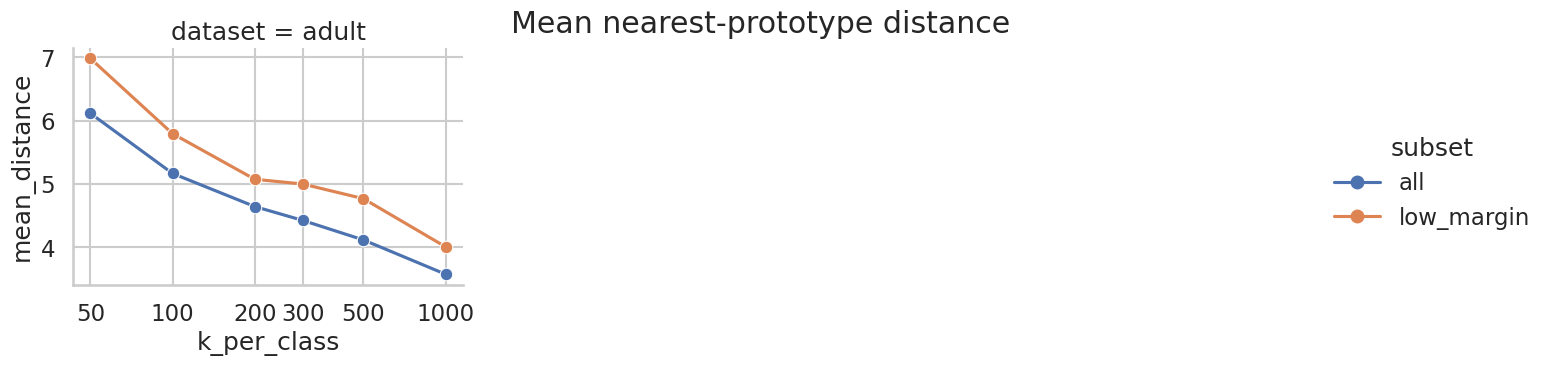

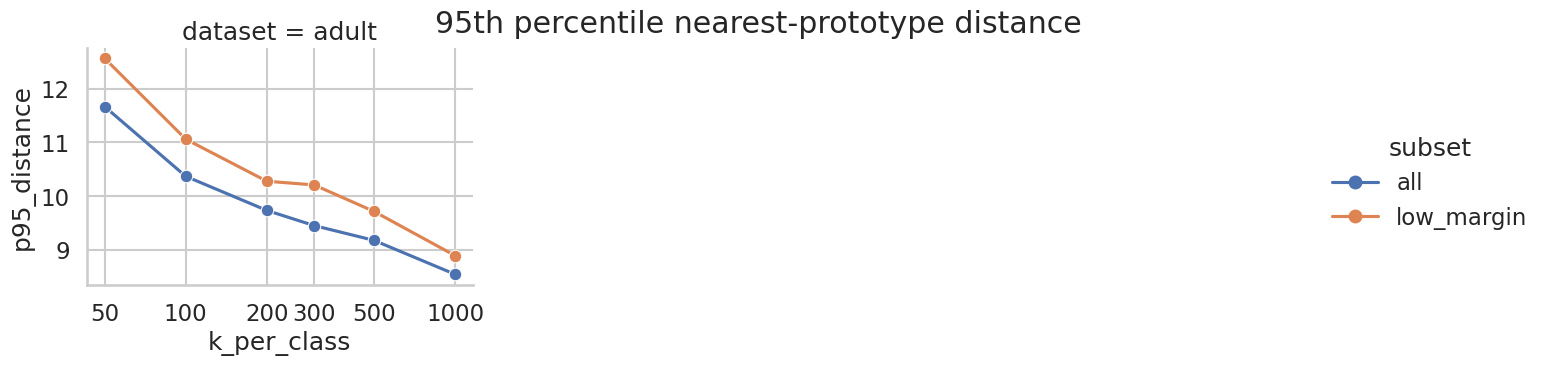

k_per_class,50,100,200,300,500,1000
dataset,,,,,,
adult,12.567015,11.061469,10.277725,10.20771,9.715154,8.891583


In [6]:
for metric_name, title in [
    ("mean_distance", "Mean nearest-prototype distance"),
    ("p95_distance", "95th percentile nearest-prototype distance"),
]:
    g = sns.relplot(
        data=compression_overall,
        x="k_per_class",
        y=metric_name,
        hue="subset",
        col="dataset",
        col_wrap=3,
        kind="line",
        marker="o",
        facet_kws={"sharey": False},
        height=3.8,
        aspect=1.2,
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(title)
    for ax in g.axes.flat:
        ax.set_xscale("log")
        ax.set_xticks(K_GRID)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    plt.show()

compression_pivot = compression_overall[
    compression_overall["subset"] == "low_margin"
].pivot(index="dataset", columns="k_per_class", values="p95_distance")
display(compression_pivot)


## 2. Certified atlas coverage and overlap on same-class training points

Now we move from generic prototype quality to CertCF-specific atlas diagnostics.

For each `k_per_class`, we actually build the atlas on the selected prototypes and then ask two questions:

1. what fraction of same-class training points lie inside at least one certified same-class polytope?
2. how much overlap is there among those certified regions on the empirical data support?

This is much closer to the real purpose of the subsampled atlas. If coverage plateaus early, then a larger `k_per_class` may not buy much. If overlap grows much faster than coverage, then larger `k_per_class` is creating redundancy that can hurt query time.


In [7]:
coverage_rows = []
overlap_rows = []
for dataset_name in tqdm(DATASETS, desc="Coverage diagnostics"):
    bundle = bundles[dataset_name]
    for k in K_GRID:
        coverage_rows.extend(_coverage_rows(bundle, k))
        overlap_rows.extend(_overlap_rows(bundle, k))

coverage_df = pd.DataFrame(coverage_rows)
coverage_overall = coverage_df[coverage_df["class_label"] == "overall"].copy()
overlap_df = pd.DataFrame(overlap_rows)
overlap_overall = overlap_df[overlap_df["class_label"] == "overall"].copy()

display(coverage_overall.sort_values(["dataset", "k_per_class"]).head(24))
display(overlap_overall.sort_values(["dataset", "k_per_class"]).head(24))


Coverage diagnostics:   0%|          | 0/1 [00:00<?, ?it/s]

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:24<00:00, 12.46s/it]


,dataset,lirpa_method,class_label,k_per_class,n_eval,n_covered,coverage_rate,build_time_s,n_selected_total
2,adult,backward,overall,50,8000,157,0.019625,1.490581,100
5,adult,backward,overall,100,8000,206,0.025750,2.510003,200
8,adult,backward,overall,200,8000,327,0.040875,4.892009,400
11,adult,backward,overall,300,8000,387,0.048375,7.511631,600
14,adult,backward,overall,500,8000,498,0.062250,12.625063,1000
17,adult,backward,overall,1000,8000,741,0.092625,24.996093,2000


,dataset,lirpa_method,class_label,k_per_class,n_eval,covered_rate,multi_cover_rate,mean_cover_count,mean_cover_count_if_covered,mean_overlap_excess,build_time_s,n_selected_total
2,adult,backward,overall,50,8000,0.018000,0.002500,0.021750,1.208333,0.003750,1.490581,100
5,adult,backward,overall,100,8000,0.027500,0.003500,0.035750,1.300000,0.008250,2.510003,200
8,adult,backward,overall,200,8000,0.039125,0.003625,0.052250,1.335463,0.013125,4.892009,400
11,adult,backward,overall,300,8000,0.047750,0.005875,0.058250,1.219895,0.010500,7.511631,600
14,adult,backward,overall,500,8000,0.061375,0.012875,0.101875,1.659878,0.040500,12.625063,1000
17,adult,backward,overall,1000,8000,0.089250,0.019500,0.128250,1.436975,0.039000,24.996093,2000


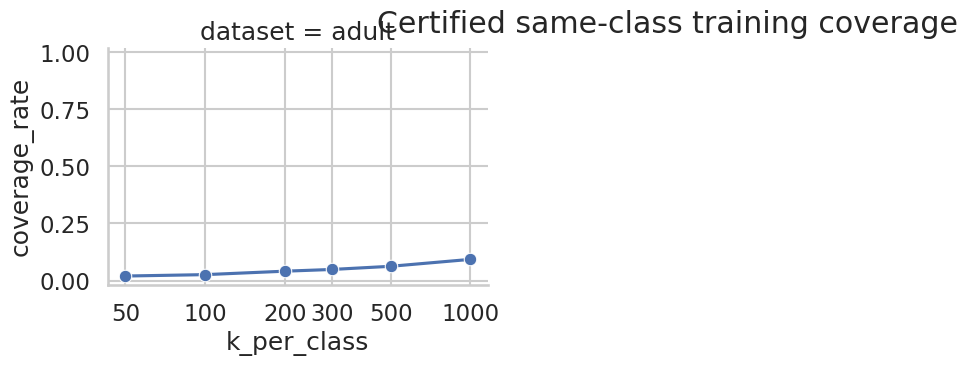

k_per_class              50       100       200       300      500       1000
dataset class_label                                                          
adult   0            0.013000  0.01625  0.027250  0.034000  0.05025  0.067000
        1            0.026250  0.03525  0.054500  0.062750  0.07425  0.118250
        overall      0.019625  0.02575  0.040875  0.048375  0.06225  0.092625

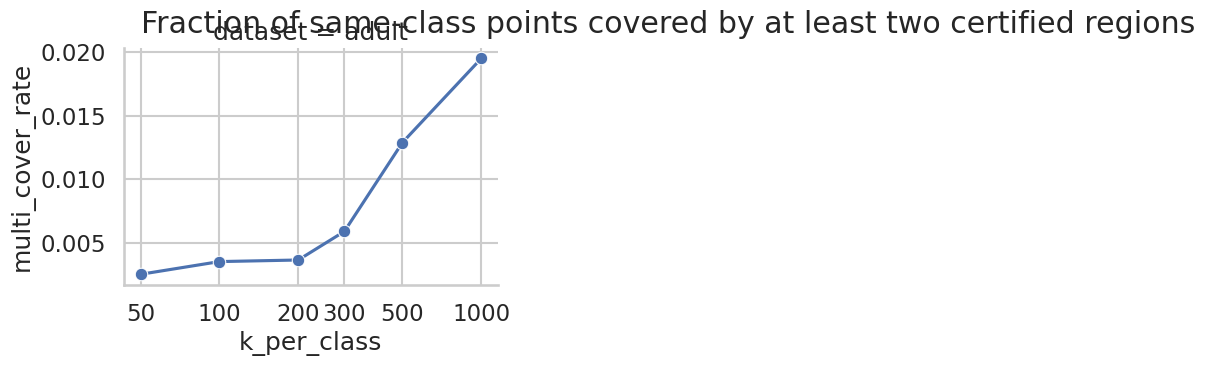

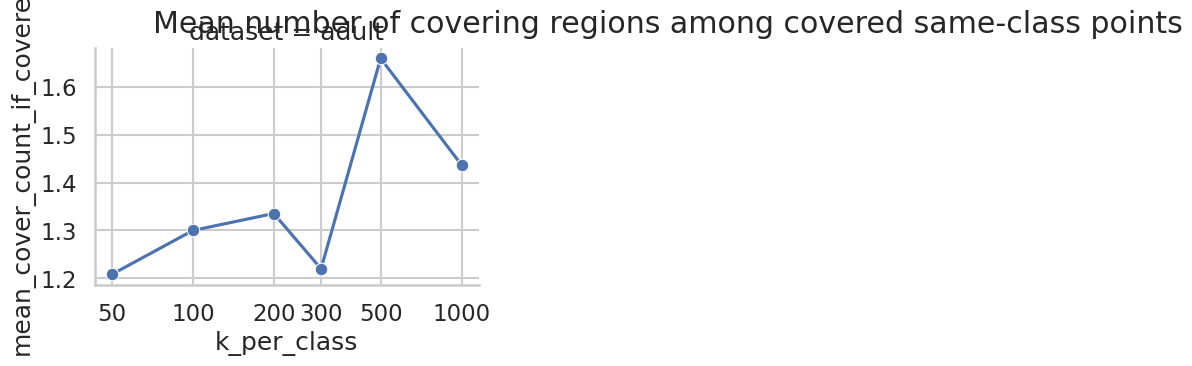

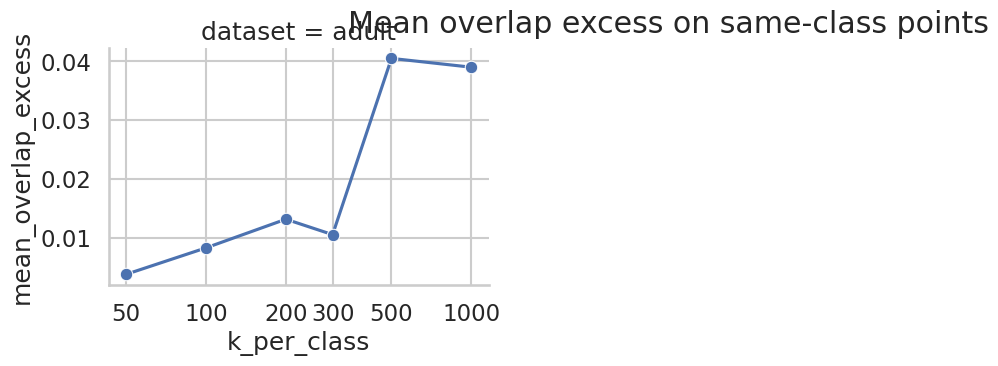

k_per_class             50       100       200       300       500      1000
dataset class_label                                                         
adult   0            0.00325  0.00275  0.005500  0.003500  0.008250  0.01075
        1            0.00175  0.00425  0.001750  0.008250  0.017500  0.02825
        overall      0.00250  0.00350  0.003625  0.005875  0.012875  0.01950

In [8]:
g = sns.relplot(
    data=coverage_overall,
    x="k_per_class",
    y="coverage_rate",
    col="dataset",
    col_wrap=3,
    kind="line",
    marker="o",
    facet_kws={"sharey": False},
    height=3.8,
    aspect=1.2,
)
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Certified same-class training coverage")
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_xticks(K_GRID)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(-0.02, 1.02)
plt.show()

display(
    coverage_df.pivot_table(
        index=["dataset", "class_label"],
        columns="k_per_class",
        values="coverage_rate",
    )
)

for metric_name, title in [
    ("multi_cover_rate", "Fraction of same-class points covered by at least two certified regions"),
    ("mean_cover_count_if_covered", "Mean number of covering regions among covered same-class points"),
    ("mean_overlap_excess", "Mean overlap excess on same-class points"),
]:
    g = sns.relplot(
        data=overlap_overall,
        x="k_per_class",
        y=metric_name,
        col="dataset",
        col_wrap=3,
        kind="line",
        marker="o",
        facet_kws={"sharey": False},
        height=3.8,
        aspect=1.2,
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(title)
    for ax in g.axes.flat:
        ax.set_xscale("log")
        ax.set_xticks(K_GRID)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    plt.show()

display(
    overlap_df.pivot_table(
        index=["dataset", "class_label"],
        columns="k_per_class",
        values="multi_cover_rate",
    )
)


## 3. Pilot CertCF query stability

Finally, we run a small fixed pilot query set for each dataset and measure what actually changes for CertCF as `k_per_class` grows.

This is the most practical view because it captures the whole effect of the subsampled atlas on:

- build time
- query success rate
- counterfactual distance
- query runtime

If the curves are already flat around `k=200`, that is strong evidence that 200 is enough. If they still move substantially, we should consider increasing the budget for that dataset.


In [9]:
pilot_rows = []
for dataset_name in tqdm(DATASETS, desc="Pilot query diagnostics"):
    bundle = bundles[dataset_name]
    for k in K_GRID:
        pilot_rows.extend(_pilot_query_rows(bundle, k))

pilot_df = pd.DataFrame(pilot_rows)
pilot_summary = (
    pilot_df.groupby(["dataset", "k_per_class"], as_index=False)
    .agg(
        n_queries=("query_idx", "count"),
        success_rate=("success", "mean"),
        mean_distance=("distance", "mean"),
        median_distance=("distance", "median"),
        mean_query_time_ms=("query_time_ms", "mean"),
        median_query_time_ms=("query_time_ms", "median"),
        build_time_s=("build_time_s", "first"),
    )
)

display(pilot_summary)


Pilot query diagnostics:   0%|          | 0/1 [00:00<?, ?it/s]

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,dataset,k_per_class,n_queries,success_rate,mean_distance,median_distance,mean_query_time_ms,median_query_time_ms,build_time_s
0,adult,50,25,1.0,10.492221,11.375980,705.299089,517.923522,1.490581
1,adult,100,25,1.0,10.133099,11.148364,1589.986655,1007.639636,2.510003
2,adult,200,25,1.0,8.929708,9.407626,2172.200520,2000.851114,4.892009
3,adult,300,25,1.0,8.725187,9.046485,4193.468164,3988.697851,7.511631
4,adult,500,25,1.0,8.255779,8.740889,4496.655954,5175.215531,12.625063
5,adult,1000,25,1.0,7.475382,7.412946,4336.390405,4072.655357,24.996093


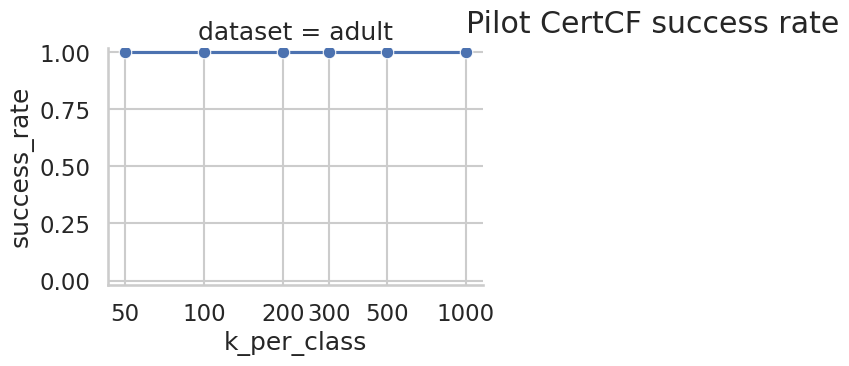

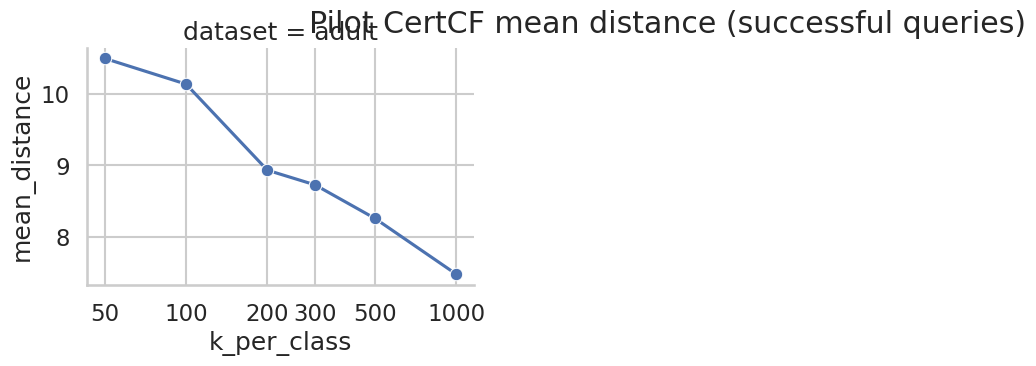

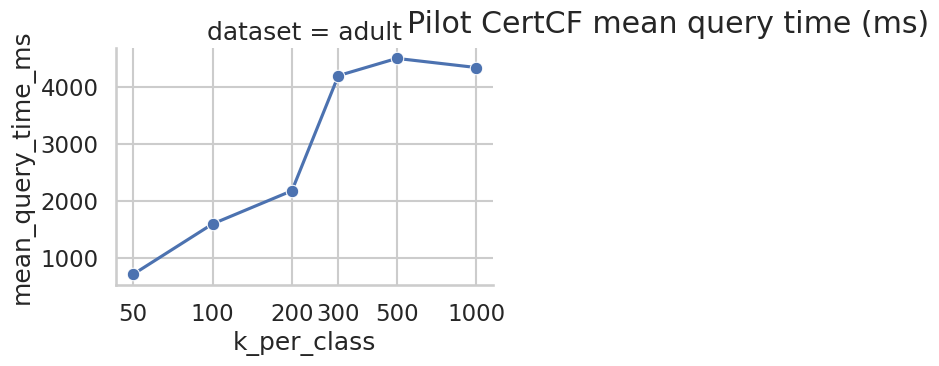

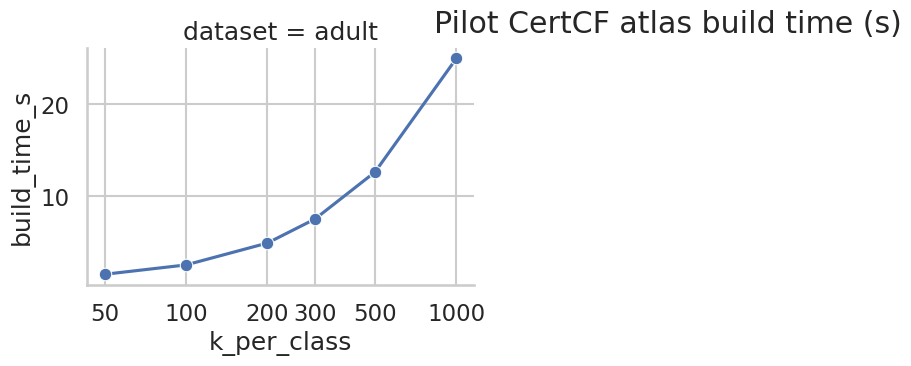

In [10]:
for metric_name, title, ylim in [
    ("success_rate", "Pilot CertCF success rate", (-0.02, 1.02)),
    ("mean_distance", "Pilot CertCF mean distance (successful queries)", None),
    ("mean_query_time_ms", "Pilot CertCF mean query time (ms)", None),
    ("build_time_s", "Pilot CertCF atlas build time (s)", None),
]:
    g = sns.relplot(
        data=pilot_summary,
        x="k_per_class",
        y=metric_name,
        col="dataset",
        col_wrap=3,
        kind="line",
        marker="o",
        facet_kws={"sharey": False},
        height=3.8,
        aspect=1.2,
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(title)
    for ax in g.axes.flat:
        ax.set_xscale("log")
        ax.set_xticks(K_GRID)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        if ylim is not None:
            ax.set_ylim(*ylim)
    plt.show()


## Heuristic recommendation

The table below picks the smallest `k_per_class` that simultaneously satisfies four soft conditions for each dataset:

- low-margin `p95` prototype distance within 10% of the best observed value
- certified coverage within 99% of the best observed value
- pilot success rate within 1 percentage point of the best observed value
- empirical overlap growth remains reasonably controlled

These thresholds are just a starting point. They are easy to tighten or loosen depending on how conservative you want to be.


In [11]:
decision_df = (
    compression_overall[compression_overall["subset"] == "low_margin"]
    [["dataset", "k_per_class", "p95_distance"]]
    .merge(
        coverage_overall[["dataset", "k_per_class", "coverage_rate"]],
        on=["dataset", "k_per_class"],
        how="inner",
    )
    .merge(
        pilot_summary[["dataset", "k_per_class", "success_rate", "mean_distance", "mean_query_time_ms", "build_time_s"]],
        on=["dataset", "k_per_class"],
        how="inner",
    )
    .merge(
        overlap_overall[["dataset", "k_per_class", "multi_cover_rate", "mean_overlap_excess"]],
        on=["dataset", "k_per_class"],
        how="inner",
    )
)


def recommend_k(group):
    group = group.sort_values("k_per_class").copy()
    best_p95 = group["p95_distance"].min()
    best_coverage = group["coverage_rate"].max()
    best_success = group["success_rate"].max()

    overlap_reference = group.loc[group["k_per_class"] == group["k_per_class"].min(), "mean_overlap_excess"].iloc[0]

    eligible = group[
        (group["p95_distance"] <= 1.10 * best_p95)
        & (group["coverage_rate"] >= 0.99 * best_coverage)
        & (group["success_rate"] >= best_success - 0.01)
        & (group["mean_overlap_excess"] <= max(0.01, 1.5 * overlap_reference))
    ]
    if not eligible.empty:
        return eligible.head(1)

    fallback = group.sort_values(
        ["success_rate", "coverage_rate", "p95_distance", "k_per_class"],
        ascending=[False, False, True, True],
    )
    return fallback.head(1)


recommendation_df = (
    decision_df.groupby("dataset", group_keys=False)
    .apply(recommend_k)
    .reset_index(drop=True)
)

comparison_at_200 = decision_df[decision_df["k_per_class"] == 200].copy()
comparison_at_200 = comparison_at_200.merge(
    recommendation_df[["dataset", "k_per_class"]].rename(columns={"k_per_class": "recommended_k"}),
    on=["dataset"],
    how="left",
)

display(recommendation_df)
display(comparison_at_200)


/tmp/ipykernel_89752/1403414761.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(recommend_k)


,dataset,k_per_class,p95_distance,coverage_rate,success_rate,mean_distance,mean_query_time_ms,build_time_s,multi_cover_rate,mean_overlap_excess
0,adult,1000,8.891583,0.092625,1.0,7.475382,4336.390405,24.996093,0.0195,0.039


,dataset,k_per_class,p95_distance,coverage_rate,success_rate,mean_distance,mean_query_time_ms,build_time_s,multi_cover_rate,mean_overlap_excess,recommended_k
0,adult,200,10.277725,0.040875,1.0,8.929708,2172.20052,4.892009,0.003625,0.013125,1000
